# Bootrsap for HMM-GLM with 3 states


In [1]:
import sys
import os

# Path to the Python executable
print("Python executable path:", sys.executable)

# Conda environment name (if applicable)
conda_prefix = os.environ.get('CONDA_PREFIX', None)
print("Conda environment path:", conda_prefix)

if conda_prefix:
    env_name = os.path.basename(conda_prefix)
    print("Conda environment name:", env_name)
else:
    print("Not in a Conda environment.")


Python executable path: C:\Users\shahe\miniconda3\python.exe
Conda environment path: C:\Users\shahe\miniconda3
Conda environment name: miniconda3


In [1]:
import sys
import os
import pickle
import ssm
import matplotlib.pyplot as plt

# Make sure we're adding the root of Project_monkey
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))  # Two levels up from notebooks
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Now this should work
#from Behaviour.scripts_beh import preprocessing_hmm_glm
from Behaviour.scripts_beh.preprocessing_hmm_glm import *
from Behaviour.scripts_beh.fit_hmm_glm_and_predictive_states_extraction import *
from Behaviour.scripts_beh.three_state_bootsrap import *

figures_dir = os.path.join(project_root, "Behaviour", "Figures")
os.makedirs(figures_dir, exist_ok=True)

### Preperation fo data

In [2]:
# From the data select the regressors we would like to include in the inpts, can be modified accordingly
# This will determine the dimension of the inputs

feature_names = [
            'color', 'direction', 'p_color', 'dist_prev_current_color',
            'p_direction', 'dist_prev_current_motion', 'prev_response', 'intercept'
        ]

In [3]:
# paramters of the model
input_dim = len(feature_names)  # Dimension of the input features, can be modified accordingly
num_states = 3 # Number of states in the HMM-GLM
obs_dim = 1 # Dimension of the observation (e.g., 1 for binary choice)
num_iters = 1500 # Number of iterations for fitting the model
tolerance = 1e-4 # Tolerance for convergence, standard value
observations = "input_driven_obs" # Type of observations, can be modified
transitions = "standard" # Type of transitions, can be modified
num_init = 15 # Number of initializations for the HMM-GLM to find the best parameter, can be modified
num_bootstraps = 1000 # Number of bootstrap samples, can be modified



In [4]:
## Let's Load the data and prepare the inputs for the HMM-GLM
data_path = os.path.join("..", "..", "Data", "sample_data.pkl")
inpts, choices, data = load_and_prepare_glmhmm_inputs(data_path, feature_names)

### In the first place, let's find out the best parameters for the HMM-GLM given a certain number of initiliazations

In [6]:
best_obs_params, best_trans_mat = find_best_parameters(
    data=data,
    num_states=num_states,
    input_dim=input_dim,
    N_iters=N_iters,
    tolerance=tolerance,
    num_initializations= num_init,
    feature_names = feature_names,
    filename="glm_best_params.pkl"
)


Running initialization 1 of 2...


  0%|          | 0/3000 [00:00<?, ?it/s]

Running initialization 2 of 2...


  0%|          | 0/3000 [00:00<?, ?it/s]

[INFO] Best Log-Likelihood: -1270.81
[INFO] Best parameters saved to: C:\Users\shahe\PycharmProjects\Project_monkey\Behaviour\results\glm_best_params.pkl


### Next, taking the best paramters, let's start the non-parametric bootstrap 

In [7]:
boot_weights, boot_transitions, boot_loglikes  = bootstrap_glmhmm_safe_exit_parametric(
    data=data,
    num_bootstrap=num_bootstraps ,
    num_states=num_states,
    input_dim=input_dim,
    N_iters=num_iters,
    tolerance=tolerance,
    feature_names=feature_names,
    results_filename="bootstrap.pkl",
    best_params_filename="glm_best_params.pkl"
)



[INFO] Resuming from 2/10 bootstraps.


 20%|██████████████████▏                                                                        | 2/10 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

...

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [02:18<00:00, 17.30s/it]

[INFO] Bootstrapped results saved to results


In [5]:
print_best_glmhmm_parameters("glm_best_params.pkl", regressor_labels = feature_names)



=== Best Transition Matrix ===
         State 0  State 1  State 2
State 0   0.5394   0.0027   0.4579
State 1   0.0001   0.8641   0.1357
State 2   0.5215   0.0000   0.4785

=== GLM Observation Weights ===

State 0:
                  Regressor   Weight
0                     color  -1.8212
1                 direction  21.9039
2                   p_color   1.3533
3   dist_prev_current_color  -0.9407
4               p_direction   0.3003
5  dist_prev_current_motion  -1.8209
6             prev_response   0.1109
7                 intercept   1.3448

State 1:
                  Regressor   Weight
0                     color  29.1823
1                 direction   7.5926
2                   p_color  -7.4814
3   dist_prev_current_color  10.8617
4               p_direction  19.2133
5  dist_prev_current_motion   7.5670
6             prev_response  -7.2307
7                 intercept  -3.3518

State 2:
                  Regressor   Weight
0                     color  77.7535
1                 directi

In [6]:
boot_weights, boot_transitions, boot_loglikes = load_glmhmm_bootstrap_results("bootstrap.pkl")


[INFO] Loaded 10 bootstrap iterations from bootstrap.pkl
  Weights shape:     (10, 3, 1, 8)
  Transitions shape: (10, 3, 3)
  Log-likelihoods:   (10,)


### Aligning HMM the same HMM states in bootstrapped iteration.
Assumes:

    - color regressor is at index 0
    - motion regressor is at index 1

In [7]:
# Reorder states in each bootstrap sample
reordered = []
for weights in boot_weights:
    color_weights = weights[:, 0, 0]   # regressor 0: color
    motion_weights = weights[:, 0, 1]  # regressor 1: motion

    color_state = np.argmax(color_weights)
    motion_state = np.argmax(motion_weights)

    # Ensure motion and color are distinct
    if color_state == motion_state:
        sorted_motion_states = np.argsort(motion_weights)[::-1]
        for alt_motion_state in sorted_motion_states:
            if alt_motion_state != color_state:
                motion_state = alt_motion_state
                break

    all_states = set(range(weights.shape[0]))
    disengaged_state = list(all_states - {color_state, motion_state})[0]

    reordered_weights = weights[[motion_state, color_state, disengaged_state], :, :]
    reordered.append(reordered_weights)

# Convert to array
reordered = np.array(reordered)  # shape: [num_bootstrap, num_states, 1, input_dim]


### Plot of mean aligned weights by states

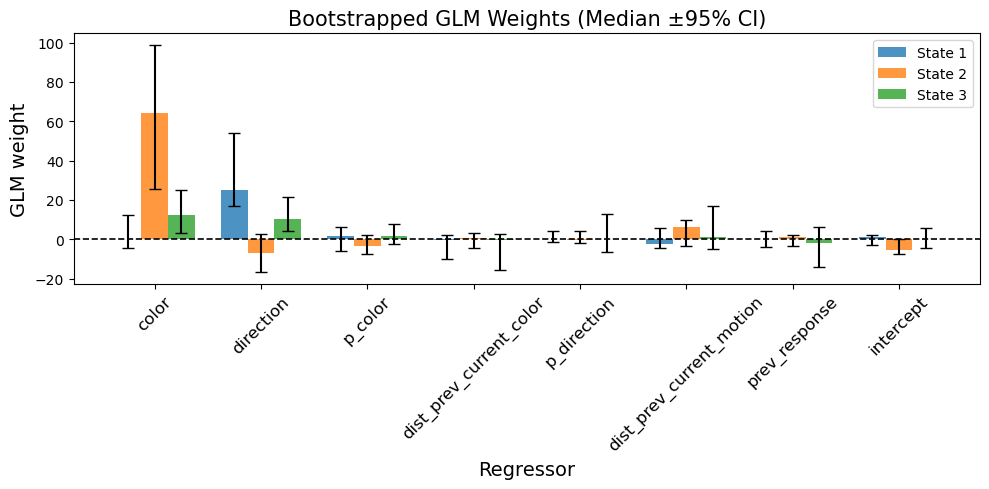

In [8]:

# Plot GLM-HMM bootstrapped weights with 95% CI
input_labels = feature_names if 'feature_names' in locals() else [f"x{i}" for i in range(input_dim)]
cols = [f"C{i}" for i in range(num_states)]

# Compute CI
lower = np.percentile(reordered, 2.5, axis=0)[:, 0, :]
upper = np.percentile(reordered, 97.5, axis=0)[:, 0, :]
median = np.percentile(reordered, 50, axis=0)[:, 0, :]

x = np.arange(input_dim)
width = 0.25
offsets = np.linspace(-width, width, num_states)

plt.figure(figsize=(10, 5))
for k in range(num_states):
    bar_x = x + offsets[k]
    bar_heights = median[k]
    bar_errors = [bar_heights - lower[k], upper[k] - bar_heights]

    plt.bar(
        bar_x,
        bar_heights,
        yerr=bar_errors,
        width=width,
        capsize=4,
        color=cols[k],
        alpha=0.8,
        label=f"State {k + 1}",
        zorder=2
    )

plt.axhline(0, color='black', linestyle='--', linewidth=1.2)
plt.xticks(x, input_labels, rotation=45, fontsize=12)
plt.ylabel("GLM weight", fontsize=14)
plt.xlabel("Regressor", fontsize=14)
plt.title("Bootstrapped GLM Weights (Median ±95% CI)", fontsize=15)
plt.legend()
plt.tight_layout()

# Save the figure to Neural/figures/
fig_path = os.path.join(figures_dir, "bootstrapped_glm_weights_ci.svg")
plt.savefig(fig_path, format='svg', bbox_inches='tight')
plt.show()


### Plot of mean aligned transition matrix by states

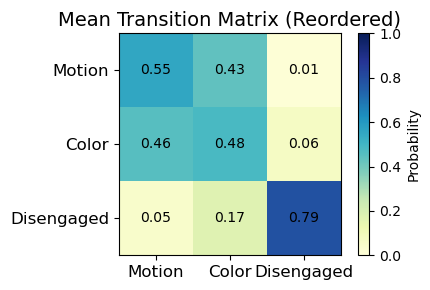

In [11]:
# Step 1: Reorder states based on GLM weight identity
reordered_transitions = []

for idx in range(len(boot_transitions)):
    color_weights = boot_weights[idx, :, 0, 0]   # regressor 0 = color
    motion_weights = boot_weights[idx, :, 0, 1]  # regressor 1 = motion

    color_state = np.argmax(color_weights)
    motion_state = np.argmax(motion_weights)

    # Ensure color_state and motion_state are distinct
    if color_state == motion_state:
        sorted_motion_states = np.argsort(motion_weights)[::-1]
        for alt_motion_state in sorted_motion_states:
            if alt_motion_state != color_state:
                motion_state = alt_motion_state
                break

    all_states = set(range(boot_weights.shape[1]))
    disengaged_state = list(all_states - {color_state, motion_state})[0]

    new_order = [motion_state, color_state, disengaged_state]
    reordered_transitions.append(boot_transitions[idx][np.ix_(new_order, new_order)])

# Stack and average transition matrices
reordered_transitions = np.stack(reordered_transitions)  # shape: [num_bootstraps, num_states, num_states]
mean_trans_mat = reordered_transitions.mean(axis=0)

# Step 2: Plot mean transition matrix with specified colormap
state_labels = ['Motion', 'Color', 'Disengaged']
num_states = mean_trans_mat.shape[0]

plt.figure(figsize=(3 + num_states * 0.5, 3))
im = plt.imshow(mean_trans_mat, cmap='YlGnBu', vmin=0, vmax=1)

# Annotate matrix with values
for i in range(num_states):
    for j in range(num_states):
        val = mean_trans_mat[i, j]
        plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10, color="black")

plt.xticks(range(num_states), state_labels, fontsize=12)
plt.yticks(range(num_states), state_labels, fontsize=12)
plt.title("Mean Transition Matrix (Reordered)", fontsize=14)
plt.colorbar(im, label="Probability")
plt.tight_layout()

# Save the figure
fig_path = os.path.join(figures_dir, "mean_transition_matrix_reordered.svg")
plt.savefig(fig_path, format='svg', bbox_inches='tight')

plt.show()


### Save and load bootstrap summary

In [25]:
summary = save_bootstrap_summary(boot_weights, boot_transitions, filename="glm_bootstrap_summary.pkl")

[INFO] Bootstrap summary saved to results


In [27]:
summary = load_bootstrap_summary("glm_bootstrap_summary.pkl")

mean_weights = summary["glm_weights"]               # shape: [num_states, 1, input_dim]
mean_transition_matrix = summary["transition_matrix"]  # shape: [num_states, num_states]
